In [ ]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [42]:
X, Y = 50,50
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 0.5 * t * np.ones(lattice.X)
T = 0.6

V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1])

In [43]:
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_k(PI/3)))

True
True
True


In [44]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=100, verbose=True, temperature=T)

F0:
Absolute error: 0.0209078095635785
Relative error: 20907809563.5785
Average old: 0j
Average: (0.002385368272570853+0j)
F_xplus:
Absolute error: 0.022777798895650472
Relative error: 0.22777798895422693
Average old: (0.09999999999999998+0j)
Average: (0.10285836468393728+0j)
F_xmin:
Absolute error: 0.022777798895650472
Relative error: 0.2277779889542269
Average old: (0.09999999999999998+0j)
Average: (0.10285836468393728+0j)
F_yplus:
Absolute error: 0.02536427764089502
Relative error: 0.2536427764114866
Average old: (-0.09999999999999998+0j)
Average: (-0.1031250651548228-1.104975486110327e-17j)
F_ymin:
Absolute error: 0.02536427764089502
Relative error: 0.2536427764114866
Average old: (-0.09999999999999998+0j)
Average: (-0.1031250651548228+1.104975486110327e-17j)
Fuu_xplus:
Absolute error: 1.747089215311455e-16
Relative error: 0.0001747089215311455
Average old: 0j
Average: (1.5951240969985703e-17+0j)
Fuu_xmin:
Absolute error: 1.7225005655377574e-16
Relative error: 0.0001722500565537757

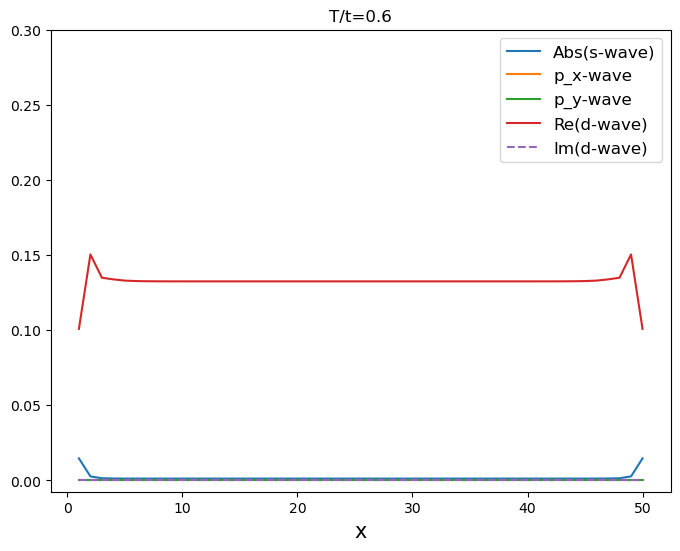

In [45]:
x = np.arange(1, X + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}")
axs.plot(x, np.abs(F_swave), label="Abs(s-wave)")
axs.plot(x, np.abs(F_px), label="p_x-wave")
axs.plot(x, np.abs(F_py), label="p_y-wave")
axs.plot(x, np.real(F_dwave), label="Re(d-wave)")
axs.plot(x, np.imag(F_dwave), "--", label="Im(d-wave)")
axs.set_xlabel("x", fontsize=15)
axs.set_ylim(None, 0.3)
axs.legend(fontsize=12, loc="best")
plt.show()
# plt.savefig('../figures/NP.pdf')
# print(F_px[40])